## Perspective Analysis

Perspective analysis generally refers to understanding different viewpoints, opinions, or angles on a particular topic, entity, or situation. In data science, this often involves:

1.  **Sentiment Analysis**: Analyzing text to determine the emotional tone (positive, negative, neutral) of a writer towards a subject. This is a common form of 'perspective' related to emotions.
2.  **Topic Modeling**: Identifying underlying themes or 'topics' within a collection of documents. Different topics can represent different perspectives or areas of discussion.
3.  **Opinion Mining**: Extracting and analyzing subjective information from source materials, often focusing on opinions expressed about products, services, or events.
4.  **Stakeholder Analysis**: In business or project management, this involves identifying different groups or individuals who have an interest in a project or system, and understanding their individual objectives, concerns, and potential impact.
5.  **Multi-Criteria Decision Analysis (MCDA)**: A framework for structuring and solving complex problems involving multiple criteria and often multiple stakeholders with different preferences or 'perspectives'.

To perform perspective analysis, you typically start with data (e.g., text, survey responses, structured data) and use techniques from Natural Language Processing (NLP), machine learning, or statistical analysis. The specific tools and methods depend heavily on the nature of your data and the kind of 'perspective' you are trying to uncover.

Could you please provide more context on the type of data you are working with or the specific 'perspective' you are interested in?

In [1]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
text = "I love learning NLP with BERT!"
result = classifier(text)
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9995285272598267}]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = {
    'patient name': ['Tharun', 'Zubeda', 'Shavkath', 'Sneha', 'Yagnavi'],
    'age': [30, 45, 22, 60, 35],
    'condition': ['Flu', 'Fracture', 'Asthma', 'Heart Disease', 'Pneumonia'],
    'oxygenlevel': [98, 95, 92, 90, 89],
    'Available beds': [True, False, True, False, True]
}

df_patients = pd.DataFrame(data)
display(df_patients.head())

,patient name,age,condition,oxygenlevel,Available beds
0,Tharun,30,Flu,98,True
1,Zubeda,45,Fracture,95,False
2,Shavkath,22,Asthma,92,True
3,Sneha,60,Heart Disease,90,False
4,Yagnavi,35,Pneumonia,89,True


In [12]:
icu_threshold_oxygen = 92
def assign_ward(row):
    if row['oxygenlevel'] < icu_threshold_oxygen or \
       row['condition'] in ['Heart Disease', 'Pneumonia']:
        return 'ICU'
    else:
        return 'General Ward'
df_patients['Ward_Assignment'] = df_patients.apply(assign_ward, axis=1)
display(df_patients)

,patient name,age,condition,oxygenlevel,Available beds,Ward_Assignment
0,Tharun,30,Flu,98,True,General Ward
1,Zubeda,45,Fracture,95,False,General Ward
2,Shavkath,22,Asthma,92,True,General Ward
3,Sneha,60,Heart Disease,90,False,ICU
4,Yagnavi,35,Pneumonia,89,True,ICU


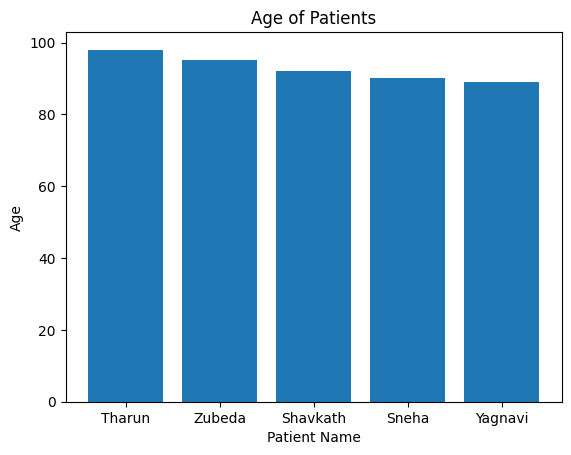

In [15]:
#visualization
plt.bar(df_patients['patient name'], df_patients['oxygenlevel'])
plt.xlabel('Patient Name')
plt.ylabel('Age')
plt.title('Age of Patients')
plt.show()

In [48]:
import pandas as pd
import numpy as np

In [49]:
df=pd.read_csv('/content/Student Mental health.csv')
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [50]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Choose your gender'] = le.fit_transform(df['Choose your gender'])
df['What is your course?'] = le.fit_transform(df['What is your course?'])
df['Marital status'] = le.fit_transform(df['Marital status'])
df['Do you have Anxiety?'] = le.fit_transform(df['Do you have Anxiety?'])
df['Do you have Panic attack?'] = le.fit_transform(df['Do you have Panic attack?'])
df['Did you seek any specialist for a treatment?'] = le.fit_transform(df['Did you seek any specialist for a treatment?'])
df['Do you have Depression?']=le.fit_transform(df['Do you have Depression?'])
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,0,18.0,17,year 1,3.00 - 3.49,0,1,0,1,0
1,8/7/2020 12:04,1,21.0,25,year 2,3.00 - 3.49,0,0,1,0,0
2,8/7/2020 12:05,1,19.0,4,Year 1,3.00 - 3.49,0,1,1,1,0
3,8/7/2020 12:06,0,22.0,33,year 3,3.00 - 3.49,1,1,0,0,0
4,8/7/2020 12:13,1,23.0,37,year 4,3.00 - 3.49,0,0,0,0,0


In [51]:
#mean
df['Do you have Depression?'].mean()

np.float64(0.3465346534653465)

In [52]:
df['Do you have Anxiety?'].mean()

np.float64(0.33663366336633666)

In [53]:
df['Do you have Panic attack?'].mean()

np.float64(0.32673267326732675)

In [54]:
depression_rate = (df['Do you have Depression?'] == 'Yes').mean() * 100
anxiety_rate = (df['Do you have Anxiety?'] == 'Yes').mean() * 100
panic_rate = (df['Do you have Panic attack?'] == 'Yes').mean() * 100
print(f"Depression Rate: {depression_rate:.2f}%")
print(f"Anxiety Rate: {anxiety_rate:.2f}%")
print(f"Panic Attack Rate: {panic_rate:.2f}%")

Depression Rate: 0.00%
Anxiety Rate: 0.00%
Panic Attack Rate: 0.00%


In [55]:
recommendations = [
    "1. Conduct regular mental health awareness programs.",
    "2. Provide counseling support for students.",
    "3. Introduce stress management workshops.",
    "4. Monitor high-risk students using predictive systems.",
    "5. Encourage peer mentoring and support groups.",
    "6. Reduce academic overload during exams.",
    "7. Create confidential online counseling portals.",
    "8. Perform monthly wellness surveys."
]

for rec in recommendations:
    print(rec)

1. Conduct regular mental health awareness programs.
2. Provide counseling support for students.
3. Introduce stress management workshops.
4. Monitor high-risk students using predictive systems.
5. Encourage peer mentoring and support groups.
6. Reduce academic overload during exams.
7. Create confidential online counseling portals.
8. Perform monthly wellness surveys.


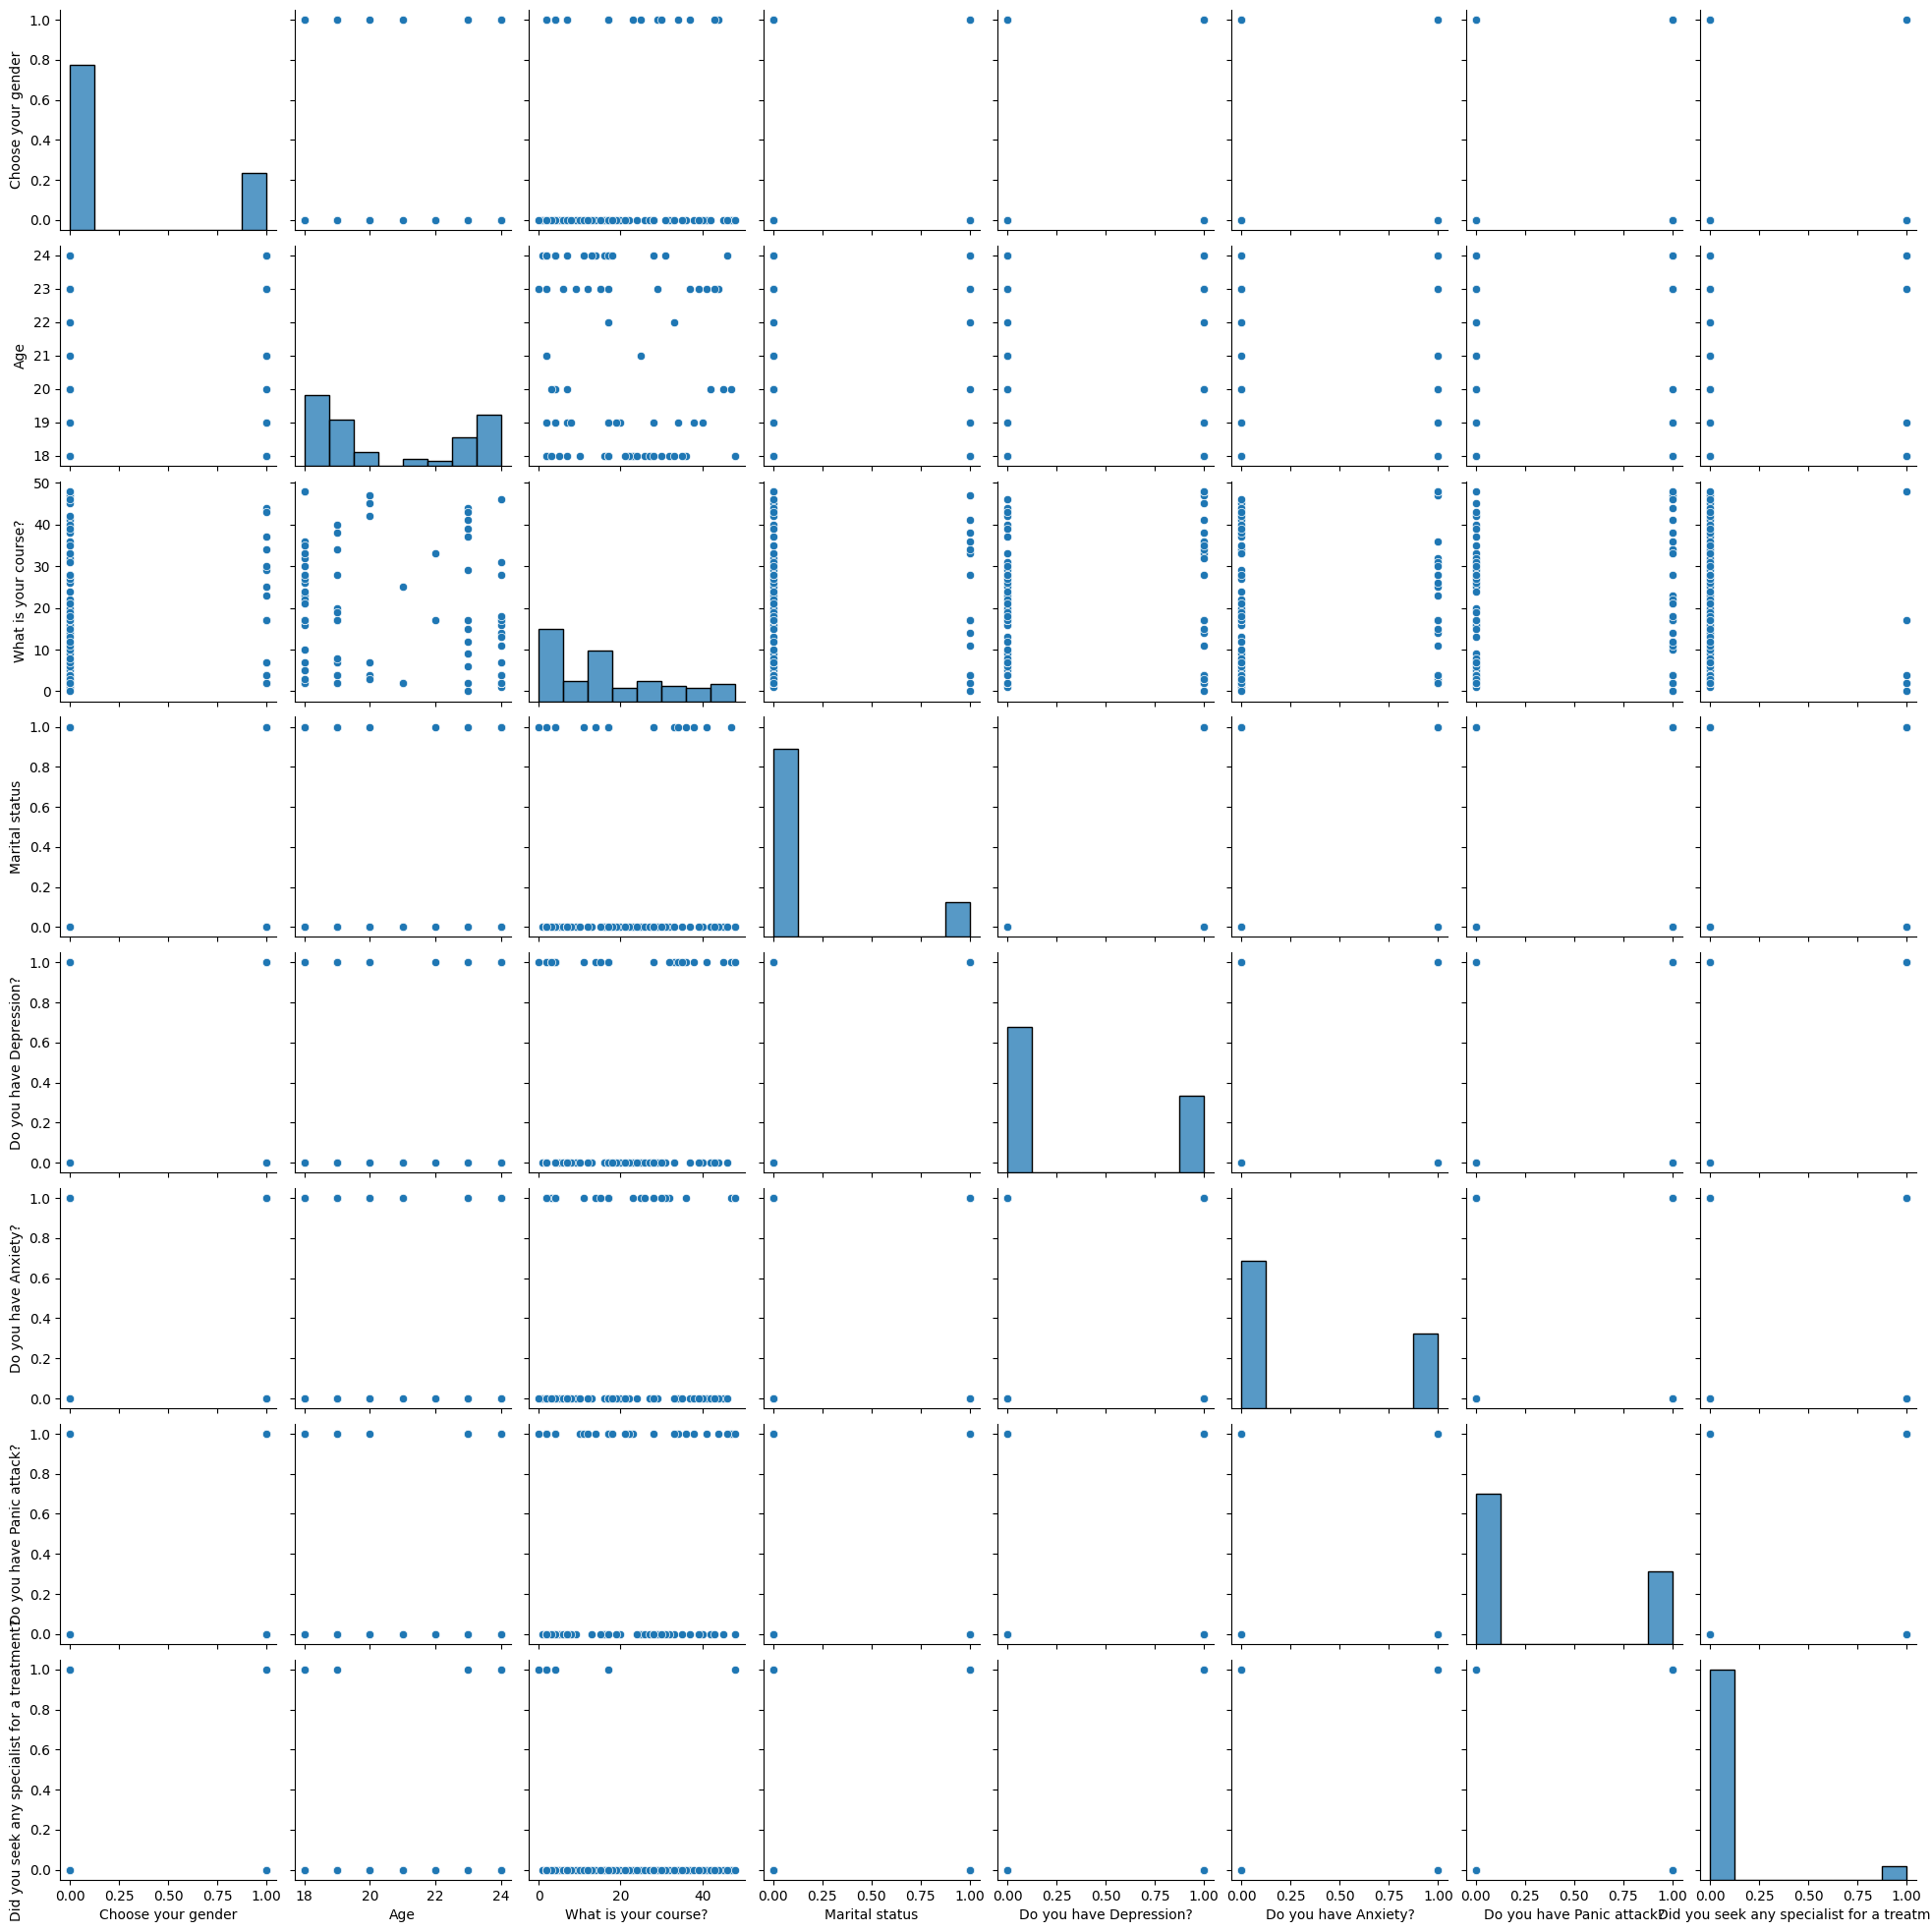

In [47]:
import seaborn as sns
sns.pairplot(df)